# SACAR LOS RESIDUOS DE ADVERTISING

## REGRESIÓN MÚLTIPLE

In [1]:
# Librerías

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("advertising.csv")

print(df)

     Unnamed: 0     TV  radio  newspaper  sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]


In [3]:
# Regresión lineal múltiple: sales ~ B0 + B1*TV + B2*radio + B3*newspaper


Y = df['sales']                            # Variable dependiente
X_v = df[['TV', 'radio', 'newspaper']]     # Variables independientes

# statsmodels no toma en cuenta el intercepto, hay que agregar la columna de unos de tamaño n

ones = np.ones([df.shape[0], 1])
X = np.hstack([ones, X_v.values])
X = pd.DataFrame(X, columns=['intercepto', 'TV', 'radio', 'newspaper'])

ols = sm.OLS(Y, X)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        18:03:27   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercepto     2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
radio          0.1885      0.009     21.893      0.000       0.172       0.206
newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

El modelo múltiple queda:

$$ \text{sales} = 2.938889 + 0.045765(\text{TV}) + 0.188530(\text{radio}) - 0.001037(\text{newspaper}) $$

El modelo tiene un R² de 0.897, por lo que explica aproximadamente el 89.7 % de la variación en las ventas. Además, el p-value general es menor a 0.05, lo cual indica que los factores sí tienen una relación significativa con `sales` cuando se analizan en conjunto. De manera individual, `TV` y `radio` son significativos, mientras que `newspaper` tiene un p-value de 0.860 y no aporta evidencia de una relación con las ventas después de considerar los otros factores.

## CÁLCULO DE LOS 6 PROBLEMAS DE LA REGRESIÓN LINEAL

In [4]:
# Calcular la y estimada y los residuos

y_hat = results.predict(X)
E = Y - y_hat

res = pd.DataFrame({
    'y': Y,
    'y_hat': y_hat,
    'residuo': E
})

res.head()

,y,y_hat,residuo
0,22.1,20.523974,1.576026
1,10.4,12.337855,-1.937855
2,9.3,12.307671,-3.007671
3,18.5,17.597830,0.902170
4,12.9,13.188672,-0.288672


La fórmula a utilizar es $e = y - \hat{y}$. Un residuo positivo indica que el valor real quedó arriba de la predicción y uno negativo indica que el modelo predijo de más.

## 1. No linealidad

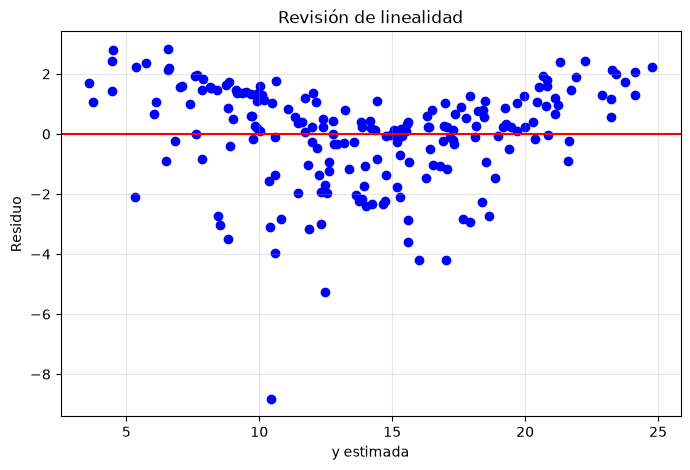

In [5]:
# Residuos contra y estimada

plt.figure(figsize=(8, 5))
plt.scatter(y_hat, E, color='blue')
plt.axhline(0, color='red')
plt.xlabel('y estimada')
plt.ylabel('Residuo')
plt.title('Revisión de linealidad')
plt.grid(alpha=0.3)
plt.show()

En la gráfica puedo observar una curva clara en los residuos. Cuando la `y` estimada es baja o alta predominan los residuos positivos, mientras que en la parte central aparecen más residuos negativos. Como los puntos no están distribuidos al azar alrededor de cero, considero que sí existe un problema de no linealidad y que el modelo está dejando fuera alguna relación entre las variables.

## 2. Correlación en los errores

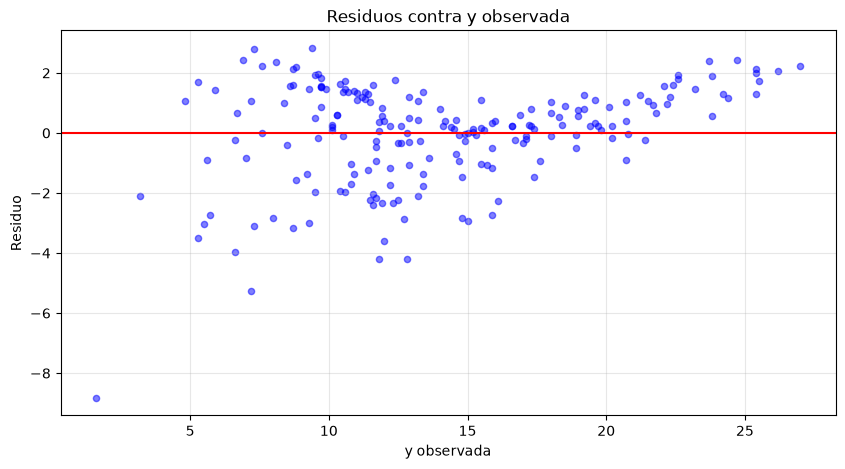

In [6]:
# Revisar los residuos contra y observada

plt.figure(figsize=(10, 5))
plt.scatter(Y, E, color='blue', alpha=0.5, s=20)
plt.axhline(0, color='red')
plt.xlabel('y observada')
plt.ylabel('Residuo')
plt.title('Residuos contra y observada')
plt.grid(alpha=0.3)
plt.show()

Al comparar los residuos con la `y` observada, noto que los valores bajos de ventas presentan varios residuos negativos y que en los valores altos predominan los positivos. Los puntos no forman una nube aleatoria alrededor de cero, sino una tendencia ascendente. Siguiendo este criterio, considero que sí existe una señal de correlación en los errores.

## 3. Varianza no constante en los errores

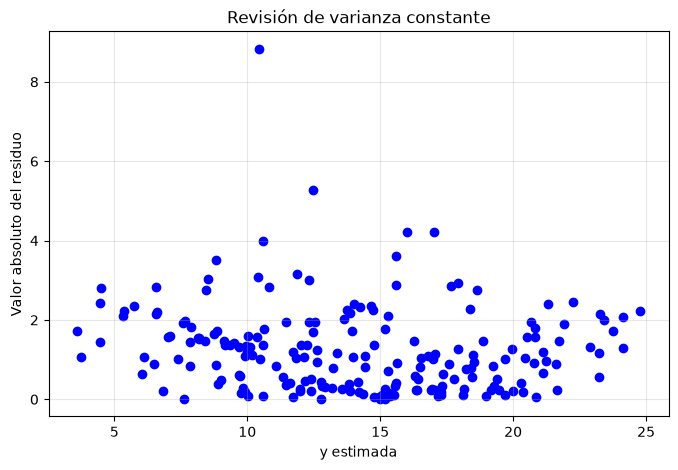

In [7]:
# Valor absoluto del residuo contra y estimada

plt.figure(figsize=(8, 5))
plt.scatter(y_hat, np.abs(E), color='blue')
plt.xlabel('y estimada')
plt.ylabel('Valor absoluto del residuo')
plt.title('Revisión de varianza constante')
plt.grid(alpha=0.3)
plt.show()

El tamaño de los residuos no se mantiene igual a lo largo de la `y` estimada. Los errores más grandes aparecen principalmente entre predicciones de 10 y 18, mientras que en los extremos la dispersión es menor. Aunque no se forma un embudo perfecto, sí observo evidencia de que la varianza de los errores no es constante.

## 4. Valores atípicos

Observaciones atípicas: [  6 131]


,y,y_hat,residuo / sigma
5,7.2,12.478348,-3.131602
130,1.6,10.427687,-5.237397


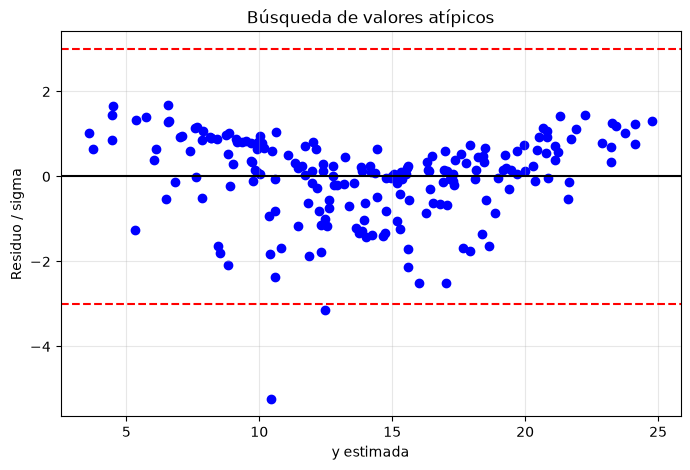

In [8]:
# Residuo dividido entre la desviación del error

n = len(Y)
p = X.shape[1]
sigma = np.sqrt(np.sum(E ** 2) / (n - p))
E_std = E / sigma

atipicos = np.where(np.abs(E_std) >= 3)[0]
print('Observaciones atípicas:', atipicos + 1)

display(pd.DataFrame({
    'y': Y.iloc[atipicos],
    'y_hat': y_hat.iloc[atipicos],
    'residuo / sigma': E_std.iloc[atipicos]
}))

plt.figure(figsize=(8, 5))
plt.scatter(y_hat, E_std, color='blue')
plt.axhline(0, color='black')
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.xlabel('y estimada')
plt.ylabel('Residuo / sigma')
plt.title('Búsqueda de valores atípicos')
plt.grid(alpha=0.3)
plt.show()

Al aplicar el criterio $|e|/\sigma \geq 3$, encontré dos observaciones atípicas. La observación 6 tiene una venta real de 7.2, una predicción de 12.48 y un residuo estandarizado de -3.13; la observación 131 tiene una venta real de 1.6, una predicción de 10.43 y un residuo estandarizado de -5.24. En ambos casos el modelo predijo ventas mucho mayores a las observadas, especialmente en la observación 131.

## 5. Puntos palanca

Límite (p + 1) / n: 0.02
Número de puntos palanca: 83


,Observación,h,residuo
16,17,0.086334,-0.323657
101,102,0.070234,0.557513
165,166,0.069199,-2.323721
75,76,0.057043,-3.158322
5,6,0.047481,-5.278348


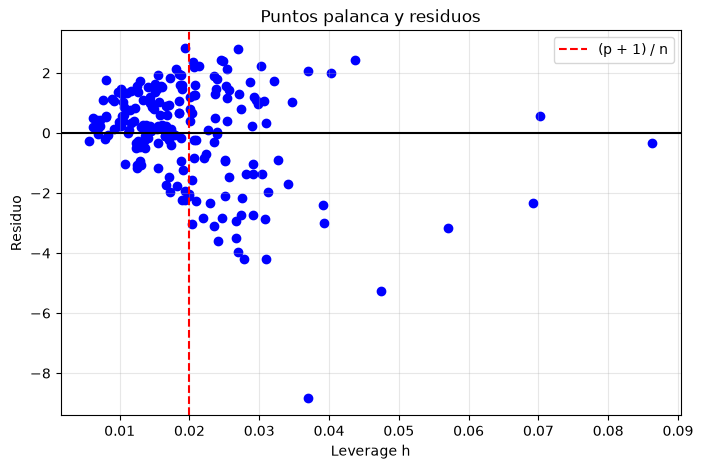

In [9]:
# Calcular el leverage de cada observación

inf = results.get_influence()
h = inf.hat_matrix_diag
p = X_v.shape[1]
h_lim = (p + 1) / n

palanca = np.where(h >= h_lim)[0]
print('Límite (p + 1) / n:', h_lim)
print('Número de puntos palanca:', len(palanca))

# Las 5 observaciones con mayor leverage
mayores = np.argsort(h)[::-1][:5]
display(pd.DataFrame({
    'Observación': mayores + 1,
    'h': h[mayores],
    'residuo': E.iloc[mayores]
}))

plt.figure(figsize=(8, 5))
plt.scatter(h, E, color='blue')
plt.axvline(h_lim, color='red', linestyle='--', label='(p + 1) / n')
plt.axhline(0, color='black')
plt.xlabel('Leverage h')
plt.ylabel('Residuo')
plt.title('Puntos palanca y residuos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El límite calculado con $(p+1)/n$ es 0.02 y se identificaron 83 posibles puntos palanca, ubicados a la derecha de la línea roja. La observación 17 tiene el valor de palanca más alto, 0.0863, pero su residuo es pequeño. En cambio, la observación 6 tiene una palanca de 0.0475 y un residuo de -5.28, por lo que convendría revisarla primero. Esto demuestra que un punto con palanca alta no necesariamente tiene un error grande.

## 6. Colinealidad

,Factor,VIF
0,TV,1.004611
1,radio,1.144952
2,newspaper,1.145187


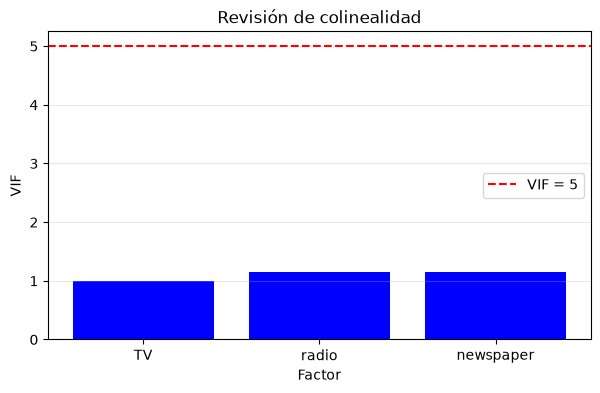

In [10]:
# Calcular el VIF de cada factor

vif = []
for i in range(1, X.shape[1]):
    vif.append(variance_inflation_factor(X.values, i))

vif = pd.DataFrame({
    'Factor': X.columns[1:],
    'VIF': vif
})

display(vif)

plt.figure(figsize=(7, 4))
plt.bar(vif['Factor'], vif['VIF'], color='blue')
plt.axhline(5, color='red', linestyle='--', label='VIF = 5')
plt.xlabel('Factor')
plt.ylabel('VIF')
plt.title('Revisión de colinealidad')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Los valores VIF de `TV`, `radio` y `newspaper` se encuentran entre 1.00 y 1.15, muy por debajo del límite de 5. Por ello, no observo un problema de colinealidad, ya que los tres factores no están aportando prácticamente la misma información al modelo.

## CONCLUSIÓN

El modelo explica aproximadamente el 89.7 % de la variación en las ventas y muestra que `TV` y `radio` tienen una relación significativa con `sales`, mientras que `newspaper` no resulta significativo. En el análisis de residuos encontré señales de no linealidad, correlación y varianza no constante, además de dos valores atípicos y 83 posibles puntos palanca. No se detectó un problema de colinealidad. A partir de estos resultados, considero que el modelo tiene una buena capacidad para explicar las ventas, aunque todavía podría mejorarse para representar la forma que aparece en los residuos.